# Visual Data Analysis & Experiment Insights

這個 Notebook 包含 10 種關鍵的視覺化圖表，涵蓋原始資料分析（EDA）、極端值觀察，以及實驗日誌的成效評估。你可以一次預覽所有圖表，最後再決定哪些最適合保留到最終的報告中。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 設定全域圖表樣式
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] # 支援中文顯示

## 1. 載入資料集與日誌

In [2]:
# 讀取訓練資料與測試資料
train_df = pd.read_csv('../dataset/train.csv')
test_df = pd.read_csv('../dataset/test.csv')

# 讀取實驗日誌與預測統計
exp_log_df = pd.read_csv('../experiments/experiment_log.csv')
try:
    pred_stats_df = pd.read_csv('../result/prediction_stats_log.csv')
except:
    pred_stats_df = pd.DataFrame()

print(f"Train shape: {train_df.shape}")
print(f"Experiment Log shape: {exp_log_df.shape}")

Train shape: (423, 11)
Experiment Log shape: (149, 21)


## 圖表 1: 目標變數分佈 (Class Imbalance)

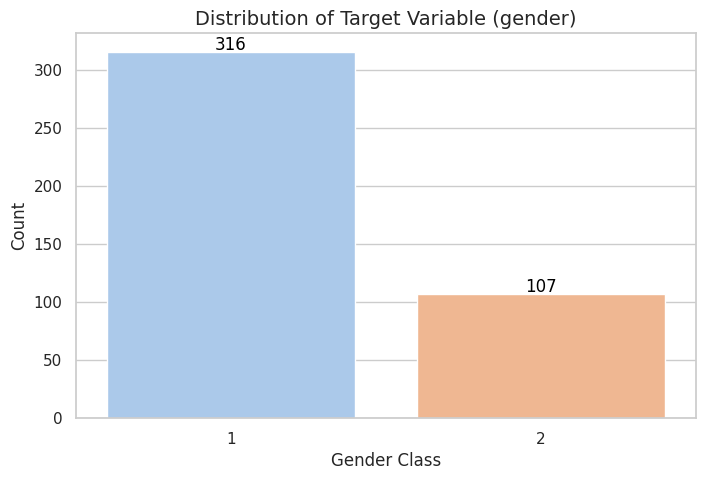

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='gender', palette='pastel')
plt.title('Distribution of Target Variable (gender)', fontsize=14)
plt.xlabel('Gender Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# 加上數值標籤
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()
# 洞察: 明顯存在類別不平衡，Class 1 (男性) 數量約為 Class 2 (女性) 的 3 倍。

## 圖表 2: 資料缺失值熱力圖 (Missing Values)

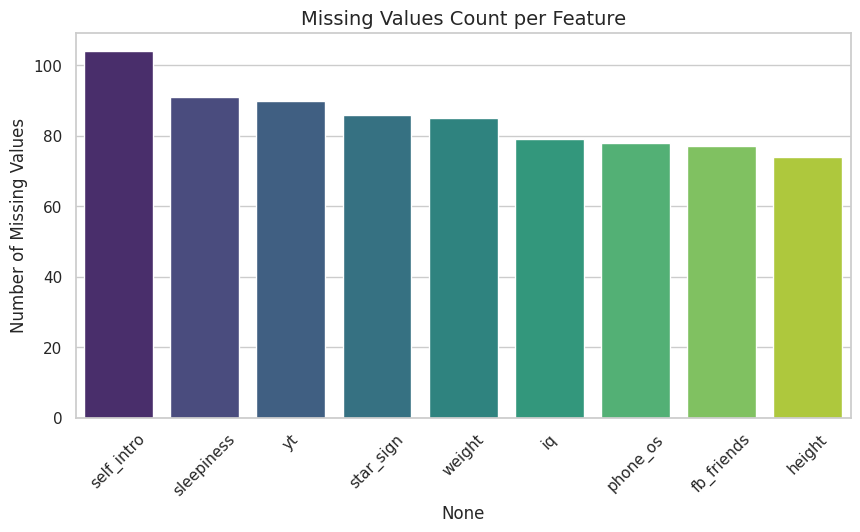

self_intro    24.59%
sleepiness    21.51%
yt            21.28%
star_sign     20.33%
weight        20.09%
iq            18.68%
phone_os      18.44%
fb_friends     18.2%
height        17.49%
dtype: str


In [4]:
missing_counts = train_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')
plt.title('Missing Values Count per Feature', fontsize=14)
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

# 顯示具體缺失比例
print((missing_counts / len(train_df) * 100).round(2).astype(str) + '%')

## 圖表 3: 數值特徵分佈 (過濾極端值前 vs 後)

## 圖表 3-2: 實驗 Pipeline 補值後的數值分佈 (模擬 Grouped M/F Median)

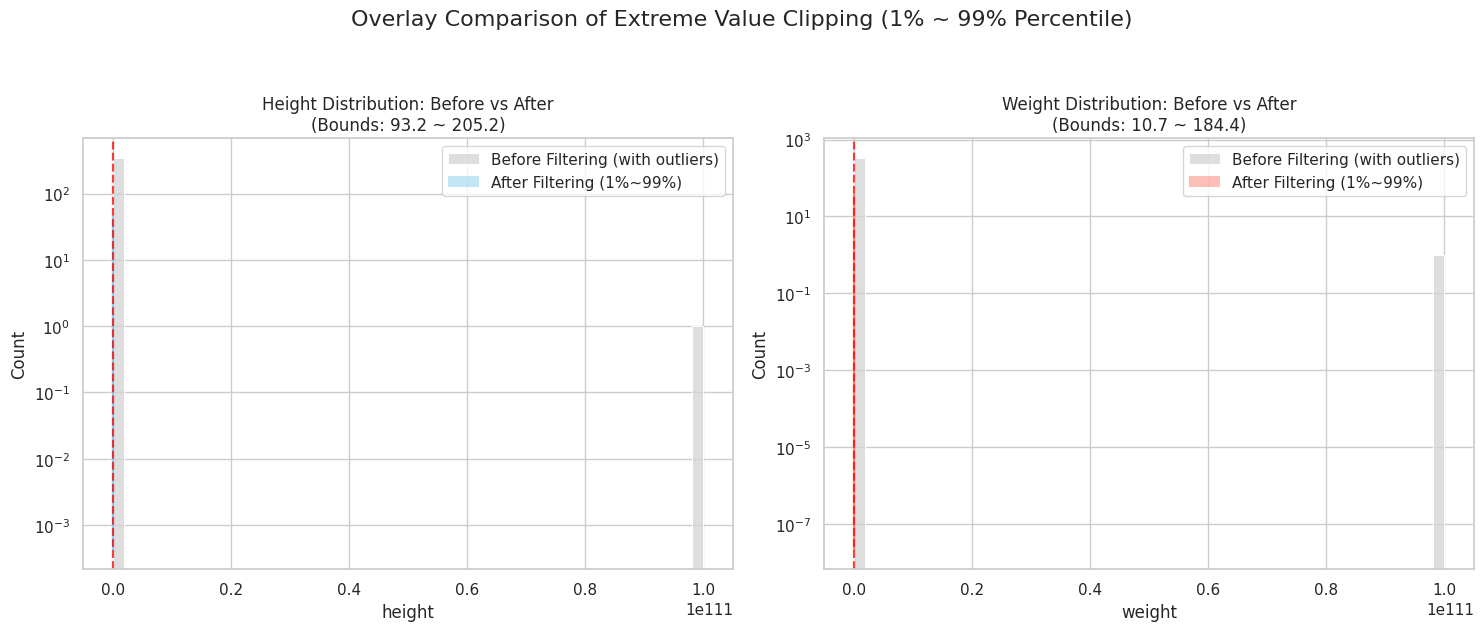

In [ ]:
# 過濾極端值的暫時 DataFrame
numeric_cols = ['height', 'weight']
filtered_df = train_df.copy()
for col in numeric_cols:
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
    # 移除異常極端值以利視覺化
    filtered_df = filtered_df[(filtered_df[col] > 0) & (filtered_df[col] < 300)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(filtered_df['height'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Height Distribution (Filtered)')

sns.histplot(filtered_df['weight'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Weight Distribution (Filtered)')

plt.tight_layout()
plt.show()

## 圖表 4: 箱型圖 - 極端與離群值檢視 (Outliers)

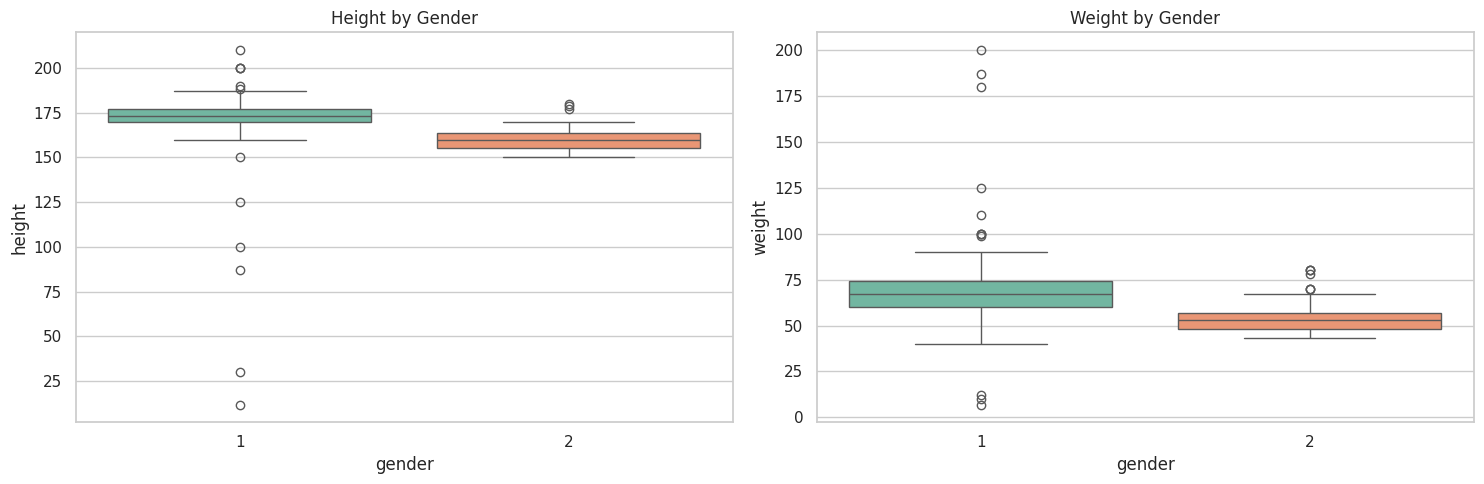

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='gender', y='height', data=filtered_df, ax=axes[0], palette='Set2')
axes[0].set_title('Height by Gender')

sns.boxplot(x='gender', y='weight', data=filtered_df, ax=axes[1], palette='Set2')
axes[1].set_title('Weight by Gender')

plt.tight_layout()
plt.show()

## 圖表 5: 類別型特徵分佈

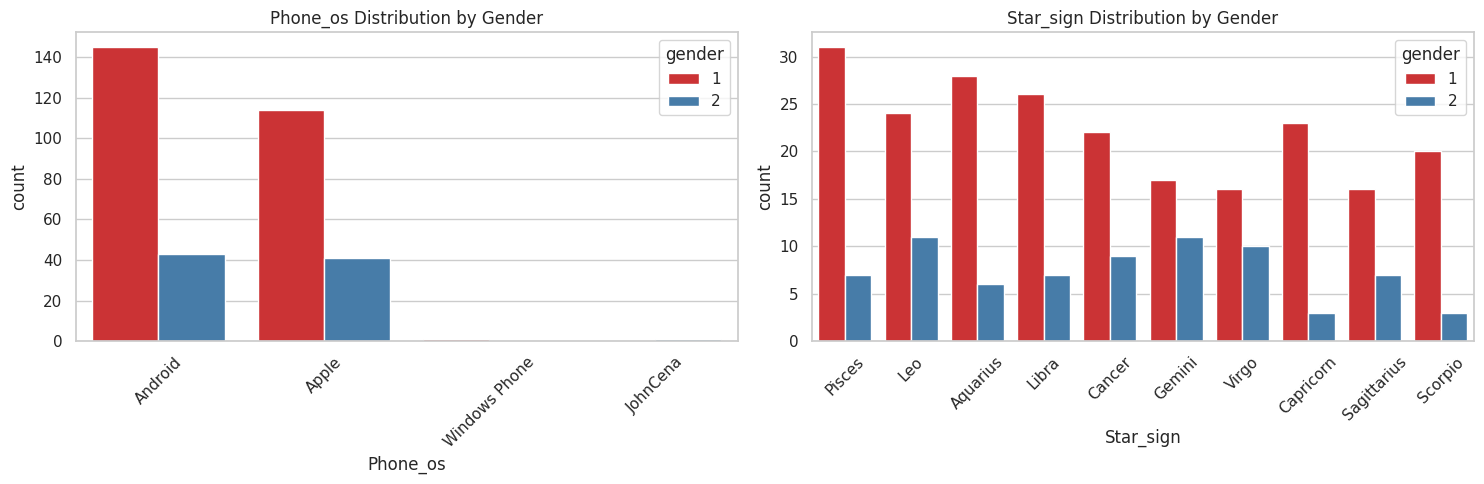

In [14]:
cat_cols = ['phone_os', 'star_sign']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 替換成完整的 DataFrame 並過濾中文字避免缺少字型而顯示方塊
temp_df = train_df.copy()
if 'star_sign' in temp_df.columns:
    # 建立星座中轉英字典
    sign_map = {
        '處女座': 'Virgo', '射手座': 'Sagittarius', '雙子座': 'Gemini', 
        '牡羊座': 'Aries', '天秤座': 'Libra', '雙魚座': 'Pisces', 
        '水瓶座': 'Aquarius', '摩羯座': 'Capricorn', '金牛座': 'Taurus', 
        '巨蟹座': 'Cancer', '獅子座': 'Leo', '天蠍座': 'Scorpio'
    }
    # .str.strip() 可以去除多餘的空白，再進行映射
    temp_df['star_sign'] = temp_df['star_sign'].str.strip().map(lambda x: sign_map.get(x, x))

for i, col in enumerate(cat_cols):
    if col in temp_df.columns:
        sns.countplot(data=temp_df, x=col, hue='gender', ax=axes[i], palette='Set1', 
                      order=temp_df[col].value_counts().index[:10])
        axes[i].set_title(f'{col.capitalize()} Distribution by Gender')
        axes[i].set_xlabel(col.capitalize(), fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 圖表 6: 數值特徵相關性熱力圖 (Correlation Heatmap)

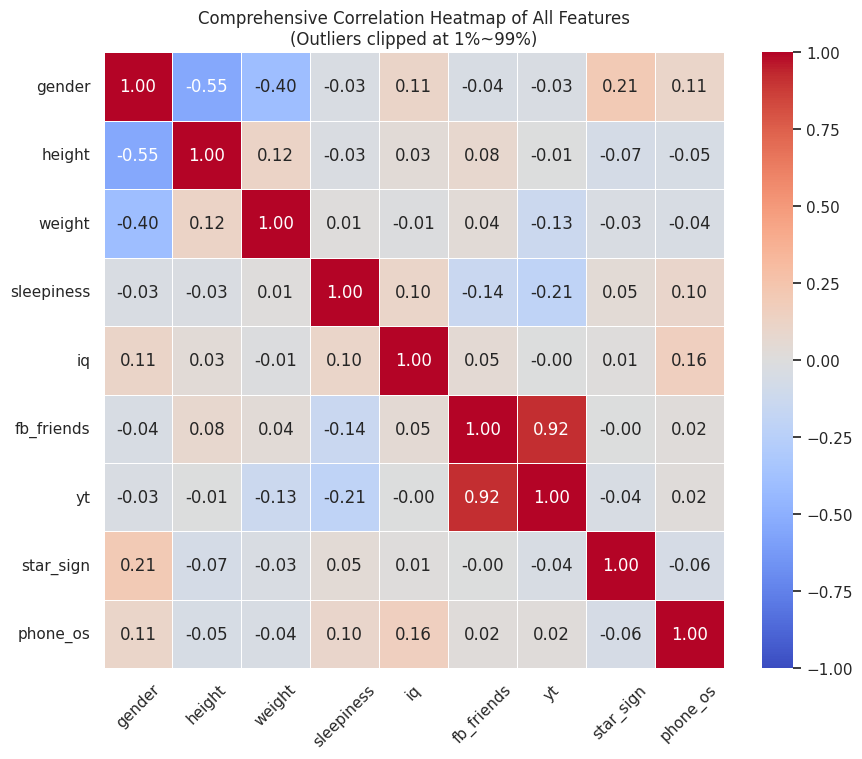

In [33]:
# 將更多原始資料欄位轉為數值型態來做相關性分析
corr_df_raw = train_df.copy()

# 數值型特徵先做強迫轉換，無法轉換的會變 NaN
# 注意：sleepiness 屬於能直接計算相關性的特徵
numeric_cols_all = ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt', 'gender']
for col in numeric_cols_all:
    if col in corr_df_raw.columns:
        corr_df_raw[col] = pd.to_numeric(corr_df_raw[col], errors='coerce')

# 過濾極端值以避免受極大/極小值影響相關性（以 1% ~ 99% Percentile 作為過濾邊界）
if 'height' in corr_df_raw.columns:
    height_lower = corr_df_raw['height'].quantile(0.01)
    height_upper = corr_df_raw['height'].quantile(0.99)
    corr_df_raw.loc[(corr_df_raw['height'] < height_lower) | (corr_df_raw['height'] > height_upper), 'height'] = np.nan
    
if 'weight' in corr_df_raw.columns:
    weight_lower = corr_df_raw['weight'].quantile(0.01)
    weight_upper = corr_df_raw['weight'].quantile(0.99)
    corr_df_raw.loc[(corr_df_raw['weight'] < weight_lower) | (corr_df_raw['weight'] > weight_upper), 'weight'] = np.nan

# 把無序類別型資料用 Target Encoding (Mean Encoding) 轉成數值
# 這是一種能將「無序類別」轉換成「與目標變數產生實質數學關係」的編碼方式
categorical_cols = ['star_sign', 'phone_os']
for col in categorical_cols:
    if col in corr_df_raw.columns and 'gender' in corr_df_raw.columns:
        # 計算每個類別下 gender 的平均值
        target_mean = corr_df_raw.groupby(col)['gender'].mean()
        corr_df_raw[col] = corr_df_raw[col].map(target_mean)

# 挑選出需要分析的欄位
target_cols = ['gender', 'height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt', 'star_sign', 'phone_os']
available_cols = [c for c in target_cols if c in corr_df_raw.columns]

# 計算相關矩陣 (因為已經做了 Target Encoding 與數值轉換，這裡可以使用 pearson)
corr_matrix = corr_df_raw[available_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Comprehensive Correlation Heatmap of All Features\n(Outliers clipped at 1%~99%)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 圖表 7: 歷次實驗 F1-Score 成效走勢

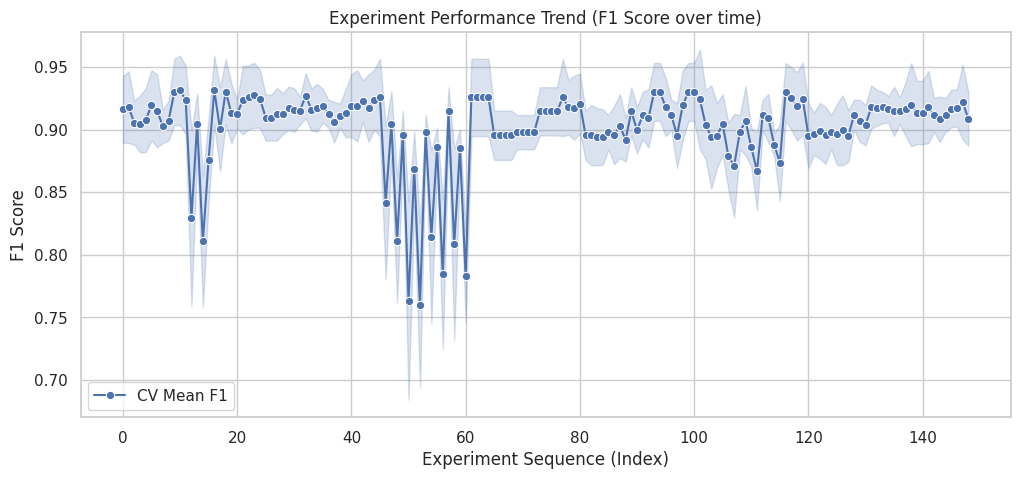

In [15]:
if not exp_log_df.empty and 'mean_f1' in exp_log_df.columns:
    # 建立一個序列索引代表實驗順序
    exp_log_df['run_id'] = exp_log_df.index
    
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=exp_log_df, x='run_id', y='mean_f1', marker="o", color='b', label='CV Mean F1')
    
    # 加上標準差陰影
    if 'std_f1' in exp_log_df.columns:
        plt.fill_between(exp_log_df['run_id'], 
                         exp_log_df['mean_f1'] - exp_log_df['std_f1'], 
                         exp_log_df['mean_f1'] + exp_log_df['std_f1'], 
                         alpha=0.2, color='b')
    
    plt.title('Experiment Performance Trend (F1 Score over time)')
    plt.xlabel('Experiment Sequence (Index)')
    plt.ylabel('F1 Score')
    plt.show()
else:
    print("Experiment log doesn't contain necessary CV F1 metrics.")

## 圖表 8: 模型種類 (Model) 效能比較

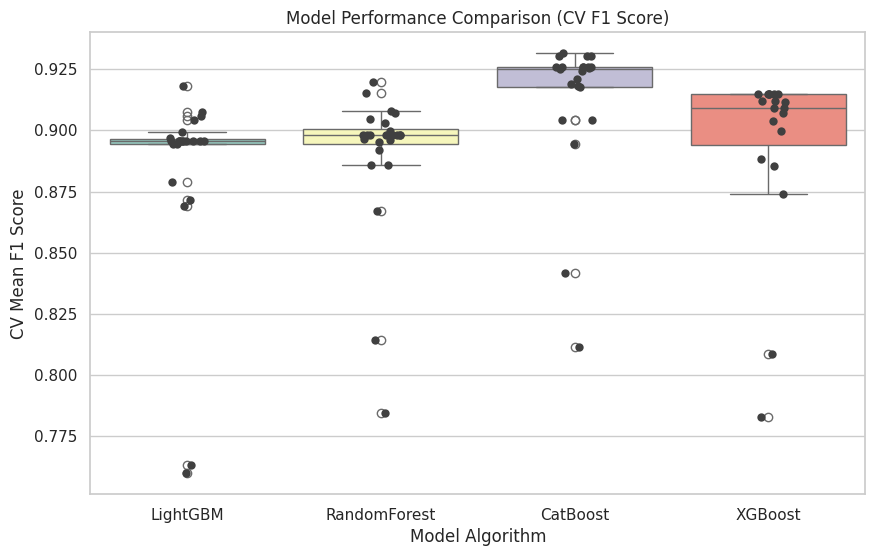

In [16]:
import re

if not exp_log_df.empty and 'mean_f1' in exp_log_df.columns:
    # 嘗試從 name 欄位萃取模型名稱 (例如 RF, CB, LGBM, XGB)
    def extract_model(name):
        if pd.isna(name): return 'Unknown'
        name_upper = name.upper()
        if 'CB' in name_upper or 'CATBOOST' in name_upper: return 'CatBoost'
        if 'RF' in name_upper or 'RANDOMFOREST' in name_upper: return 'RandomForest'
        if 'LGBM' in name_upper or 'LIGHTGBM' in name_upper: return 'LightGBM'
        if 'XGB' in name_upper: return 'XGBoost'
        return 'Other'
        
    exp_log_df['extracted_model'] = exp_log_df['name'].apply(extract_model)
    
    # 只取辨識得出特定模型的記錄
    model_df = exp_log_df[exp_log_df['extracted_model'] != 'Other']
    
    if not model_df.empty:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=model_df, x='extracted_model', y='mean_f1', palette='Set3')
        sns.stripplot(data=model_df, x='extracted_model', y='mean_f1', color='.25', size=6, jitter=True)
        plt.title('Model Performance Comparison (CV F1 Score)')
        plt.ylabel('CV Mean F1 Score')
        plt.xlabel('Model Algorithm')
        plt.show()
    else:
         print("Not enough specific models parsed from 'name' column.")
else:
    print("Column 'mean_f1' not found in experiment logs.")

## 圖表 9: 補值策略分析 (Imputation Methods)

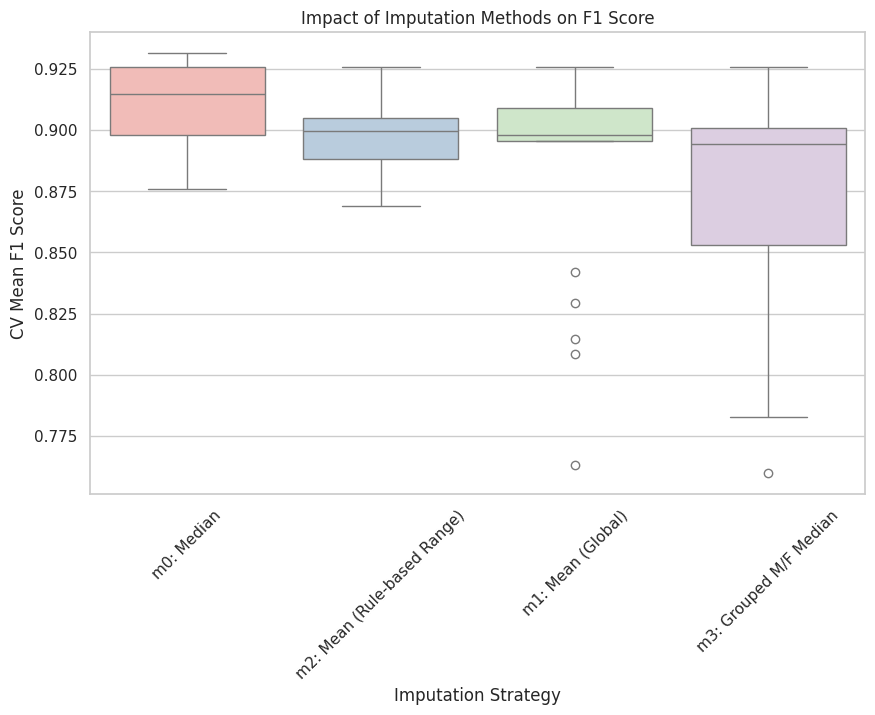

In [17]:
if not exp_log_df.empty and 'mean_f1' in exp_log_df.columns:
    # 嘗試從 name 欄位萃取 method 名稱 (method0, method1, method2, method3)
    def extract_method(name):
        if pd.isna(name): return None
        match = re.search(r'(method[0-3])', str(name))
        if match:
            # 加上可讀性對應
            mapping = {
                'method0': 'm0: Median',
                'method1': 'm1: Mean (Global)',
                'method2': 'm2: Mean (Rule-based Range)',
                'method3': 'm3: Grouped M/F Median'
            }
            return mapping.get(match.group(1), match.group(1))
        return None
        
    exp_log_df['extracted_method'] = exp_log_df['name'].apply(extract_method)
    
    # 過濾出有紀錄 method 的資料
    method_df = exp_log_df.dropna(subset=['extracted_method'])
    
    if not method_df.empty:
        plt.figure(figsize=(10, 6))
        order = method_df.groupby('extracted_method')['mean_f1'].median().sort_values(ascending=False).index
        sns.boxplot(data=method_df, x='extracted_method', y='mean_f1', order=order, palette='Pastel1')
        plt.title('Impact of Imputation Methods on F1 Score')
        plt.ylabel('CV Mean F1 Score')
        plt.xlabel('Imputation Strategy')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("Could not extract any method definitions from the log names.")
else:
    print("Column 'mean_f1' not found in experiment logs.")

## 圖表 10: 最終預測類別分佈 (與訓練集比對)

In [22]:
import glob
import os

# 尋找最新的一個 submission 檔案
sub_files = glob.glob('../result/submission_*_full.csv')
if sub_files:
    latest_sub = max(sub_files, key=os.path.getmtime)
    sub_df = pd.read_csv(latest_sub)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Test Prediction Dist
    sns.countplot(data=sub_df, x='gender', ax=axes[0], palette='pastel')
    axes[0].set_title(f'Test Set Predictions ({os.path.basename(latest_sub)})')
    axes[0].set_xlabel('Predicted Gender Class')
    
    # Train Label Dist
    sns.countplot(data=train_df, x='gender', ax=axes[1], palette='pastel')
    axes[1].set_title('Training Set True Labels')
    axes[1].set_xlabel('True Gender Class')
    
    plt.tight_layout()
    plt.show()
else:
    print("No submission files found in result/ directory to compare distributions.")

No submission files found in result/ directory to compare distributions.
